In [1]:
import numpy as np
from sklearn.datasets import make_classification 
from sklearn.model_selection import train_test_split

In [2]:
x,y = make_classification(n_features=2,n_samples=100,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,random_state=41,hypercube=False,class_sep=20)

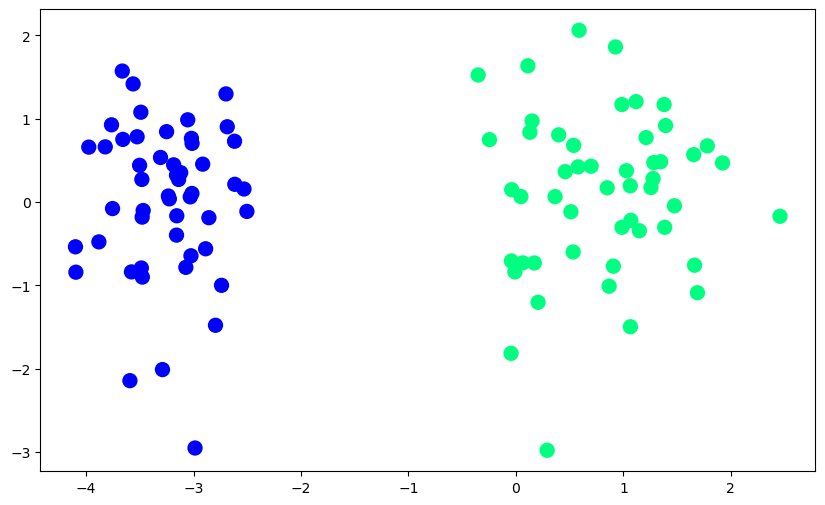

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)

In [7]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(penalty=None,solver='sag')
lor.fit(x,y)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [8]:
print(lor.coef_)
print(lor.intercept_)

[[4.80184374 0.20955708]]
[5.7777172]


In [9]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])

In [10]:
x_input = np.linspace(-3,3,100)
y_input = m1*x_input +b1

In [55]:
def gd(x,y):
    x = np.insert(x,0,1,axis=1)
    weights = np.ones(x.shape[1])
    lr = 0.5
    for i in range(10000000):
        y_hat = sigmoid(np.dot(x,weights))
        weights = weights + lr*(np.dot((y-y_hat),x)/x.shape[0])

    return weights[1:],weights[0]    

In [54]:
def sigmoid(z):
    return 1/(1-np.exp(-z))

In [56]:
coef_ , intercept_ = gd(x,y)

In [57]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [58]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1+b

(-3.0, 2.0)

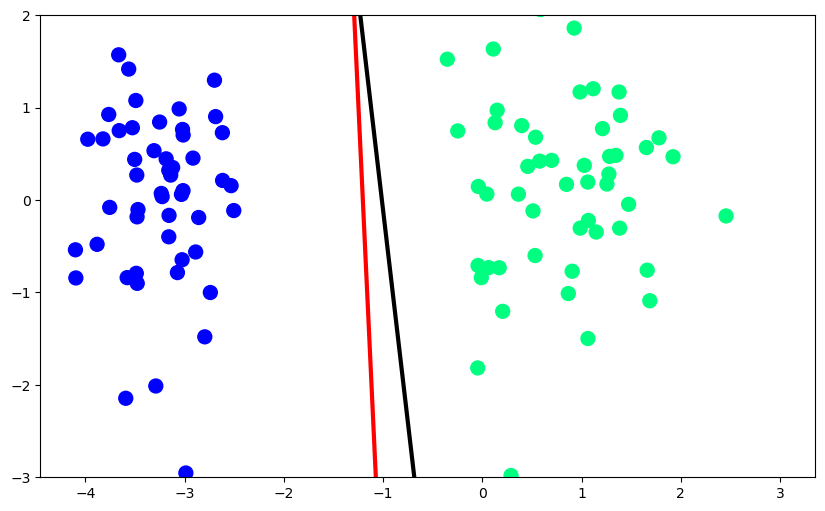

In [59]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color = 'red' , linewidth=3)
plt.plot(x_input1,y_input1,color = 'black' , linewidth=3)
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)